In [1]:
#!wget https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/bv2hvm4pmz-3.zip
#!unzip /content/bv2hvm4pmz-3.zip

--2024-11-19 16:54:09--  https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/bv2hvm4pmz-3.zip
Resolving prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com)... 52.218.57.16, 3.5.69.139, 52.218.30.192, ...
Connecting to prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com)|52.218.57.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1340049458 (1.2G) [application/zip]
Saving to: ‘bv2hvm4pmz-3.zip’

bv2hvm4pmz-3.zip    100%[===================>]   1.25G  33.4MB/s    in 41s     

2024-11-19 16:54:50 (31.5 MB/s) - ‘bv2hvm4pmz-3.zip’ saved [1340049458/1340049458]



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/content/Indoor Air Quality Monitoring @ Brindisi Airport/complete_measure_node_airport_gold.csv")

df

,id_measure;node_id;ads1115_value;ads1115_voltage;scd30_co2;scd30_temp;scd30_hum;sps30_pm05_count;sps30_pm1_count;sps30_pm1_ug;sps30_pm25_count;sps30_pm25_ug;sps30_pm4_count;sps30_pm4_ug;sps30_pm10_count;sps30_pm10_ug;sps30_pm_typ;ts_insertion
0,1;node-air-gold;1950;0.243757;606.316;29.3313;...
1,2;node-air-gold;1997;0.249633;605.303;29.3019;...
2,3;node-air-gold;1997;0.249633;605.58;29.3153;5...
3,4;node-air-gold;1977;0.247133;605.191;29.3153;...
4,5;node-air-gold;1957;0.244632;603.975;29.3019;...
...,...
7105446,7490026;node-air-gold;1663;0.207881;713.675;28...
7105447,7490027;node-air-gold;1664;0.208006;713.536;28...
7105448,7490028;node-air-gold;1645;0.205631;713.131;28...
7105449,7490029;node-air-gold;1664;0.207881;711.359;28...


In [2]:
df = pd.read_csv("/content/Indoor Air Quality Monitoring @ Brindisi Airport/complete_measure_node_airport_gold.csv", delimiter=';')

df

,id_measure,node_id,ads1115_value,ads1115_voltage,scd30_co2,scd30_temp,scd30_hum,sps30_pm05_count,sps30_pm1_count,sps30_pm1_ug,sps30_pm25_count,sps30_pm25_ug,sps30_pm4_count,sps30_pm4_ug,sps30_pm10_count,sps30_pm10_ug,sps30_pm_typ,ts_insertion
0,1,node-air-gold,1950,0.243757,606.316,29.3313,51.7258,26.4676,31.5050,3.97163,31.6969,4.19985,31.7065,4.19985,31.7126,4.19985,0.553393,2022-10-27 10:55:14
1,2,node-air-gold,1997,0.249633,605.303,29.3019,51.6693,26.3993,31.4237,3.96138,31.6152,4.18902,31.6247,4.18902,31.6308,4.18902,0.549469,2022-10-27 10:55:16
2,3,node-air-gold,1997,0.249633,605.580,29.3153,51.6327,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:18
3,4,node-air-gold,1977,0.247133,605.191,29.3153,51.7242,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:20
4,5,node-air-gold,1957,0.244632,603.975,29.3019,51.6556,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7105446,7490026,node-air-gold,1663,0.207881,713.675,28.1483,43.4067,38.6570,46.0142,5.80072,46.2946,6.13404,46.3085,6.13405,46.3175,6.13405,0.540815,2023-10-13 08:04:12
7105447,7490027,node-air-gold,1664,0.208006,713.536,28.1483,43.3792,39.3510,46.8404,5.90487,47.1258,6.24418,47.1399,6.24418,47.1491,6.24418,0.540534,2023-10-13 08:04:14
7105448,7490028,node-air-gold,1645,0.205631,713.131,28.1617,43.3243,39.4641,46.9749,5.92183,47.2612,6.26211,47.2754,6.26212,47.2845,6.26212,0.544188,2023-10-13 08:04:17
7105449,7490029,node-air-gold,1664,0.207881,711.359,28.1617,43.3655,39.8152,47.3929,5.97452,47.6817,6.31783,47.6960,6.31783,47.7052,6.31783,0.543882,2023-10-13 08:04:19


In [3]:
print(df.isnull().sum()) #checking for NULL values in the dataset

id_measure           0
node_id              0
ads1115_value        0
ads1115_voltage      0
scd30_co2            0
scd30_temp           0
scd30_hum            0
sps30_pm05_count    12
sps30_pm1_count     15
sps30_pm1_ug         0
sps30_pm25_count    17
sps30_pm25_ug        8
sps30_pm4_count     23
sps30_pm4_ug         9
sps30_pm10_count    23
sps30_pm10_ug       11
sps30_pm_typ        25
ts_insertion         0
dtype: int64


In [4]:
#Turning null values into 0's
columns_to_fill = [
    'sps30_pm05_count', 'sps30_pm1_count', 'sps30_pm25_count', 'sps30_pm4_count',
    'sps30_pm10_count', 'sps30_pm_typ', 'sps30_pm25_ug', 'sps30_pm4_ug', 'sps30_pm10_ug'
]

df[columns_to_fill] = df[columns_to_fill].fillna(0)

print(df.isnull().sum())

id_measure          0
node_id             0
ads1115_value       0
ads1115_voltage     0
scd30_co2           0
scd30_temp          0
scd30_hum           0
sps30_pm05_count    0
sps30_pm1_count     0
sps30_pm1_ug        0
sps30_pm25_count    0
sps30_pm25_ug       0
sps30_pm4_count     0
sps30_pm4_ug        0
sps30_pm10_count    0
sps30_pm10_ug       0
sps30_pm_typ        0
ts_insertion        0
dtype: int64


In [5]:
cols_to_drop=['id_measure','node_id']

df = df.drop(columns=df.filter(items=cols_to_drop).columns)

df

,ads1115_value,ads1115_voltage,scd30_co2,scd30_temp,scd30_hum,sps30_pm05_count,sps30_pm1_count,sps30_pm1_ug,sps30_pm25_count,sps30_pm25_ug,sps30_pm4_count,sps30_pm4_ug,sps30_pm10_count,sps30_pm10_ug,sps30_pm_typ,ts_insertion
0,1950,0.243757,606.316,29.3313,51.7258,26.4676,31.5050,3.97163,31.6969,4.19985,31.7065,4.19985,31.7126,4.19985,0.553393,2022-10-27 10:55:14
1,1997,0.249633,605.303,29.3019,51.6693,26.3993,31.4237,3.96138,31.6152,4.18902,31.6247,4.18902,31.6308,4.18902,0.549469,2022-10-27 10:55:16
2,1997,0.249633,605.580,29.3153,51.6327,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:18
3,1977,0.247133,605.191,29.3153,51.7242,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:20
4,1957,0.244632,603.975,29.3019,51.6556,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7105446,1663,0.207881,713.675,28.1483,43.4067,38.6570,46.0142,5.80072,46.2946,6.13404,46.3085,6.13405,46.3175,6.13405,0.540815,2023-10-13 08:04:12
7105447,1664,0.208006,713.536,28.1483,43.3792,39.3510,46.8404,5.90487,47.1258,6.24418,47.1399,6.24418,47.1491,6.24418,0.540534,2023-10-13 08:04:14
7105448,1645,0.205631,713.131,28.1617,43.3243,39.4641,46.9749,5.92183,47.2612,6.26211,47.2754,6.26212,47.2845,6.26212,0.544188,2023-10-13 08:04:17
7105449,1664,0.207881,711.359,28.1617,43.3655,39.8152,47.3929,5.97452,47.6817,6.31783,47.6960,6.31783,47.7052,6.31783,0.543882,2023-10-13 08:04:19


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7105451 entries, 0 to 7105450
Data columns (total 16 columns):
 #   Column            Dtype  
---  ------            -----  
 0   ads1115_value     int64  
 1   ads1115_voltage   float64
 2   scd30_co2         float64
 3   scd30_temp        float64
 4   scd30_hum         float64
 5   sps30_pm05_count  float64
 6   sps30_pm1_count   float64
 7   sps30_pm1_ug      float64
 8   sps30_pm25_count  float64
 9   sps30_pm25_ug     float64
 10  sps30_pm4_count   float64
 11  sps30_pm4_ug      float64
 12  sps30_pm10_count  float64
 13  sps30_pm10_ug     float64
 14  sps30_pm_typ      float64
 15  ts_insertion      object 
dtypes: float64(14), int64(1), object(1)
memory usage: 867.4+ MB


In [7]:
df['ts_insertion'] = pd.to_datetime(df['ts_insertion'])

int_cols = df.select_dtypes(include=['int64']).columns
df[int_cols] = df[int_cols].astype('float64')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7105451 entries, 0 to 7105450
Data columns (total 16 columns):
 #   Column            Dtype         
---  ------            -----         
 0   ads1115_value     float64       
 1   ads1115_voltage   float64       
 2   scd30_co2         float64       
 3   scd30_temp        float64       
 4   scd30_hum         float64       
 5   sps30_pm05_count  float64       
 6   sps30_pm1_count   float64       
 7   sps30_pm1_ug      float64       
 8   sps30_pm25_count  float64       
 9   sps30_pm25_ug     float64       
 10  sps30_pm4_count   float64       
 11  sps30_pm4_ug      float64       
 12  sps30_pm10_count  float64       
 13  sps30_pm10_ug     float64       
 14  sps30_pm_typ      float64       
 15  ts_insertion      datetime64[ns]
dtypes: datetime64[ns](1), float64(15)
memory usage: 867.4 MB


In [30]:
df2 = df.head(6000000)

In [39]:
filtered_data_after_sep = df[df['ts_insertion'] > '2023-09-30']

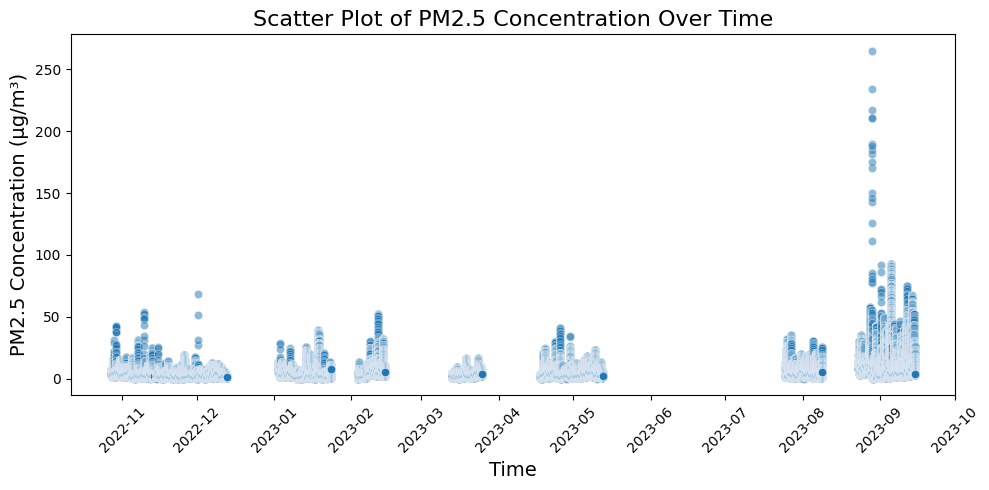

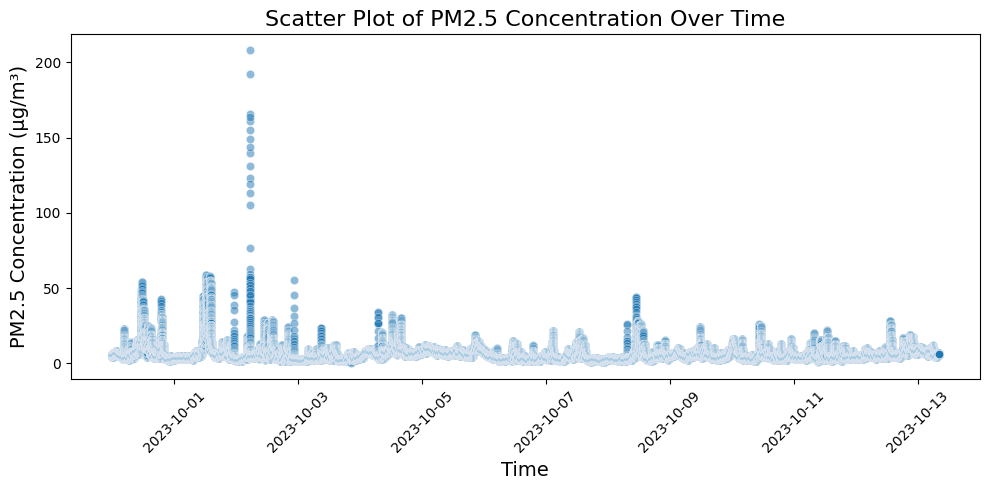

In [44]:

plt.figure(figsize=(10, 5))
sns.scatterplot(x='ts_insertion', y='sps30_pm25_ug', data=df2, alpha=0.5)

plt.xlabel('Time', fontsize=14)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=14)
plt.title('Scatter Plot of PM2.5 Concentration Over Time', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
sns.scatterplot(x='ts_insertion', y='sps30_pm25_ug', data=filtered_data_after_sep, alpha=0.5)

plt.xlabel('Time', fontsize=14)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=14)
plt.title('Scatter Plot of PM2.5 Concentration Over Time', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (df < lower_bound) | (df > upper_bound)

outliers_count = outliers.sum()
print(outliers_count)

ads1115_value       210680
ads1115_voltage     211337
scd30_co2           373905
scd30_temp           73966
scd30_hum            54224
sps30_pm05_count    393819
sps30_pm1_count     399387
sps30_pm1_ug        403064
sps30_pm25_count    402879
sps30_pm25_ug       405213
sps30_pm4_count     403460
sps30_pm4_ug        407201
sps30_pm10_count    403574
sps30_pm10_ug       408572
sps30_pm_typ        466865
ts_insertion             0
dtype: int64
